In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [12]:
!unzip "/content/instagram-dataset.zip"

Archive:  /content/instagram-dataset.zip
  inflating: comments.csv            
  inflating: follows.csv             
  inflating: likes.csv               
  inflating: photo_tags.csv          
  inflating: photos.csv              
  inflating: tags.csv                
  inflating: users.csv               


In [17]:
users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

In [20]:
# check first few rows
users.head()
photos.head()
likes.head()
comments.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [21]:
# check dataset shape
print("Users:", users.shape)
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)

Users: (100, 6)
Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)


In [23]:
# check column information
users.info()
photos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 257 non-null    int64 
 1   image link         257 non-null    object
 2   user ID            257 non-null    int64 
 3   created dat        257 non-null    object
 4   Insta filter used  257 non-null    object
 5   photo type         257 non-null    object
dtypes:

In [24]:
users.isnull().sum()
photos.isnull().sum()
likes.isnull().sum()
comments.isnull().sum()

,0
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [25]:
users.describe()
photos.describe()

,id,user ID
count,257.000000,257.000000
mean,129.000000,47.330739
std,74.333707,29.475817
min,1.000000,1.000000
25%,65.000000,23.000000
50%,129.000000,47.000000
75%,193.000000,72.000000
max,257.000000,100.000000


In [26]:
# Number of users
print("Total Users:", users['id'].nunique())

Total Users: 100


In [28]:
# Number of photos
print("Total Photos:", photos['id'].count())

Total Photos: 257


# Data Visualization

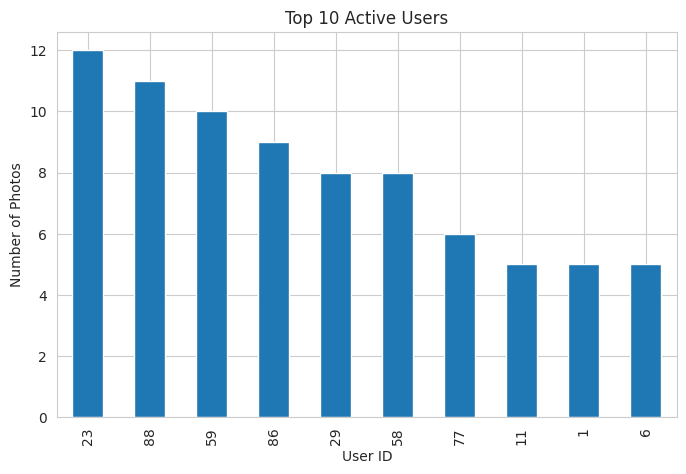

In [31]:
active_users = photos['user ID'].value_counts().head(10)

plt.figure(figsize=(8,5))
active_users.plot(kind='bar')
plt.title("Top 10 Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Photos")
plt.show()

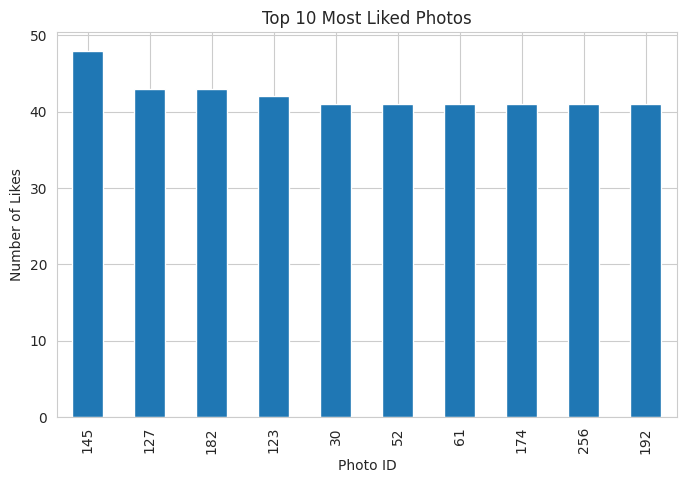

In [34]:
likes_per_photo = likes.groupby('photo').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
likes_per_photo.plot(kind='bar')
plt.title("Top 10 Most Liked Photos")
plt.xlabel("Photo ID")
plt.ylabel("Number of Likes")
plt.show()

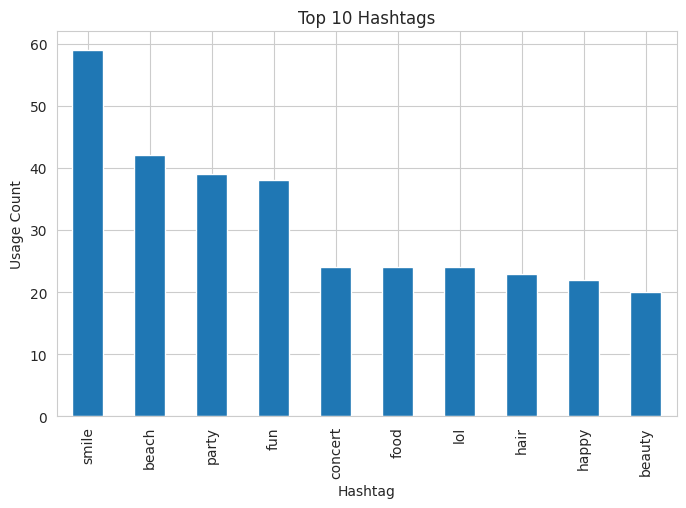

In [36]:
tag_usage = photo_tags.merge(tags, left_on='tag ID', right_on='id')

top_tags = tag_usage['tag text'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_tags.plot(kind='bar')
plt.title("Top 10 Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Usage Count")
plt.show()

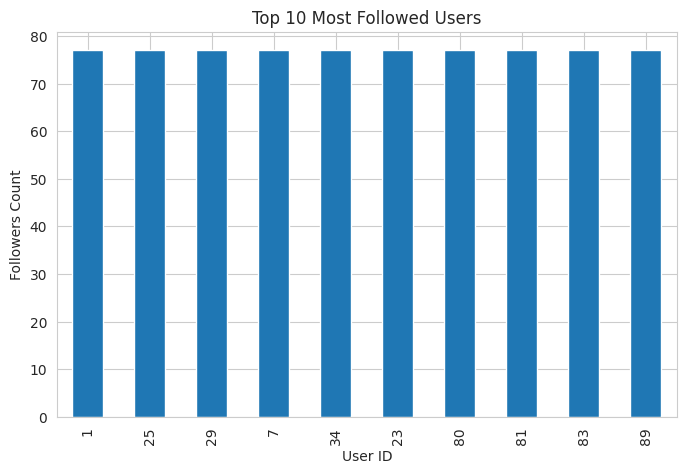

In [41]:
follows.columns = follows.columns.str.strip()
top_followed = follows['followee'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_followed.plot(kind='bar')
plt.title("Top 10 Most Followed Users")
plt.xlabel("User ID")
plt.ylabel("Followers Count")
plt.show()

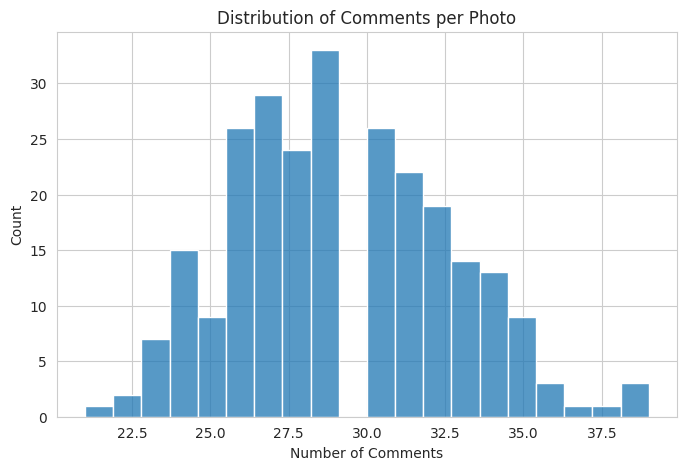

In [44]:
comments_per_photo = comments.groupby('Photo id').size()

plt.figure(figsize=(8,5))
sns.histplot(comments_per_photo, bins=20)
plt.title("Distribution of Comments per Photo")
plt.xlabel("Number of Comments")
plt.show()

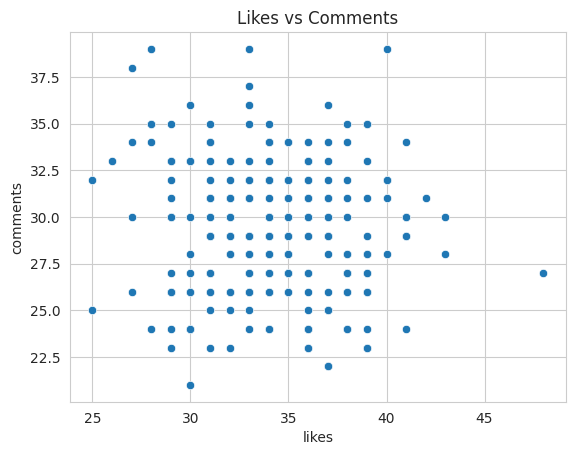

In [47]:
likes_count = likes.groupby('photo').size()
comments_count = comments.groupby('Photo id').size()

interaction = pd.DataFrame({
    'likes': likes_count,
    'comments': comments_count
}).fillna(0)

sns.scatterplot(data=interaction, x='likes', y='comments')
plt.title("Likes vs Comments")
plt.show()

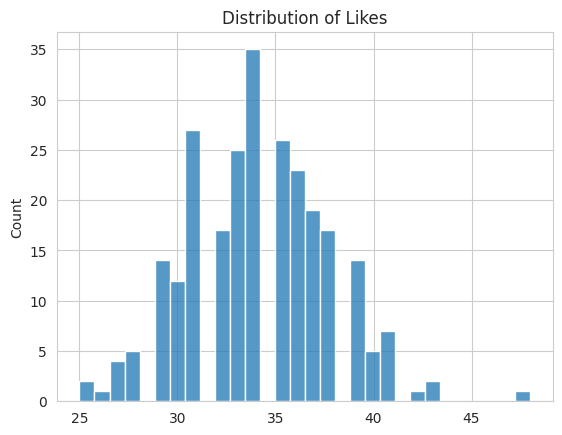

In [50]:
likes_per_photo = likes.groupby('photo').size()

sns.histplot(likes_per_photo, bins=30)
plt.title("Distribution of Likes")
plt.show()

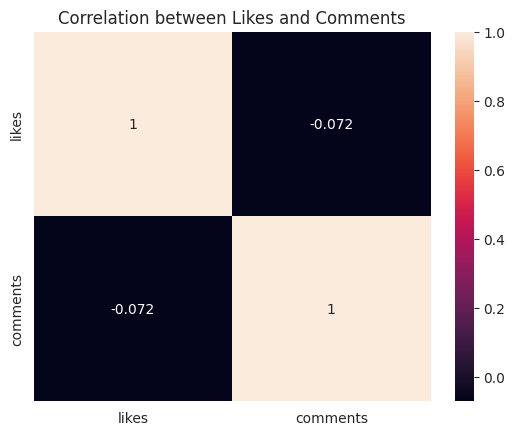

In [51]:
sns.heatmap(interaction.corr(), annot=True)
plt.title("Correlation between Likes and Comments")
plt.show()

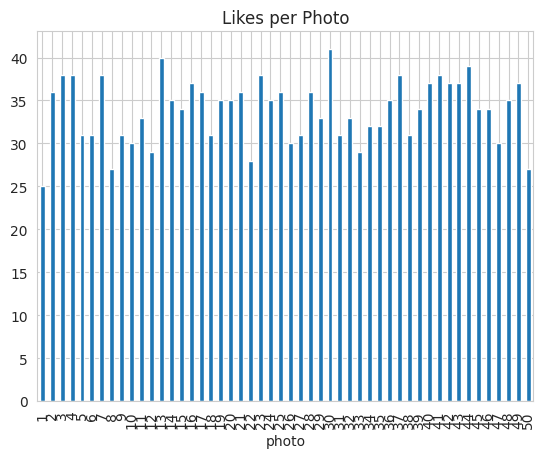

In [57]:
likes_per_photo.head(50).plot(kind='bar')
plt.title("Likes per Photo")
plt.show()

# Scikit-learn

In [59]:
likes_count = likes.groupby('photo').size()
comments_count = comments.groupby('Photo id').size()

interaction = pd.DataFrame({
    'likes': likes_count,
    'comments': comments_count
}).fillna(0)

interaction.head()

,likes,comments
1,25,25
2,36,31
3,38,27
4,38,32
5,31,27


In [60]:
interaction['engagement'] = interaction['likes'] + interaction['comments']
interaction.head()

,likes,comments,engagement
1,25,25,50
2,36,31,67
3,38,27,65
4,38,32,70
5,31,27,58


In [61]:
X = interaction[['likes','comments']]
y = interaction['engagement']

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [66]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import mean_squared_error, r2_score

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 9.709057295027838e-31
R2 Score: 1.0


# Vizulation after prediction

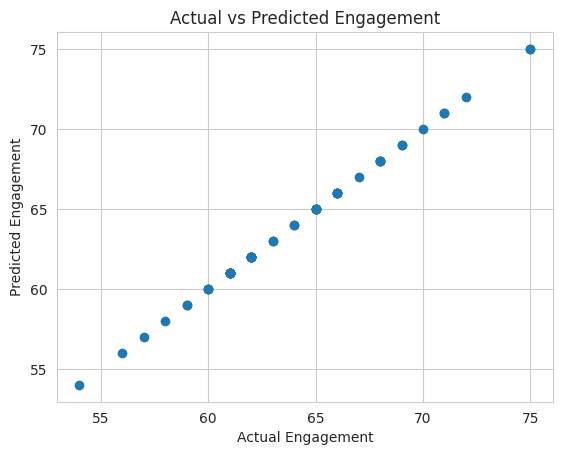

In [68]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("Actual vs Predicted Engagement")
plt.show()

In [71]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF R2 Score:", r2_score(y_test, rf_pred))

RF R2 Score: 0.9258661617187933
